### Testing prediction intervals for HMM mixture

See if the estimated variance corresponds to the true variance, on simulated data

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import sys
sys.path.append("../")

from methods.hmm_ar_1_k_states import simulate_rs_ar1, forward_algorithm


### Set parameters

In [2]:
# True parameters
beta_true  = np.array([0.2, 0.7])   # AR coefficients, non-zero
sigma_true = np.array([0.5, 1.5])
P_true = np.array([[0.95, 0.05],
                   [0.05, 0.95]])

T = 2000
y, states = simulate_rs_ar1(T, beta_true, sigma_true, P_true, seed=42)


### Forward algorithm with true parameters

In [3]:
# Use true parameters to isolate the variance formula from estimation error
alpha, _, _ = forward_algorithm(y, beta_true, sigma_true, P_true)
# alpha[t, k] = P(S_t = k | y_1, ..., y_t)


### Simulation to verify the variance formula

In [4]:
N_mc     = 100_000
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]
y_prev   = 1.0   # fixed lagged value

print(f"{'P(S=1)':>8} | {'Theoretical var':>16} | {'MC empirical var':>16} | {'Diff':>8}")
print("-" * 56)

for p in p_values:
    w     = np.array([p, 1 - p])
    means = beta_true * y_prev   # state-conditional means: mu_k = beta_k * y_{t-1}

    # Theoretical variance (law of total variance)
    mix_mean        = np.sum(w * means)
    theoretical_var = np.sum(w * sigma_true**2) + np.sum(w * (means - mix_mean)**2)

    # Monte Carlo: draw state, then draw y_t | state
    k_mc          = np.random.choice(2, size=N_mc, p=w)
    y_mc          = np.random.normal(means[k_mc], sigma_true[k_mc])
    empirical_var = np.var(y_mc)

    print(f"{p:>8.1f} | {theoretical_var:>16.4f} | {empirical_var:>16.4f} | {empirical_var - theoretical_var:>+8.4f}")


  P(S=1) |  Theoretical var | MC empirical var |     Diff
--------------------------------------------------------
     0.1 |           2.0725 |           2.0651 |  -0.0074
     0.3 |           1.7025 |           1.7058 |  +0.0033
     0.5 |           1.3125 |           1.3124 |  -0.0001
     0.7 |           0.9025 |           0.9010 |  -0.0015
     0.9 |           0.4725 |           0.4730 |  +0.0005


### Empirical coverage

In [5]:
z_95 = norm.ppf(0.975)

covered = []
for t in range(T - 1):
    # Predicted state distribution one step ahead
    w     = alpha[t] @ P_true
    means = beta_true * y[t]

    # Mixture mean and variance
    mix_mean = np.sum(w * means)
    mix_var  = np.sum(w * sigma_true**2) + np.sum(w * (means - mix_mean)**2)
    mix_sd   = np.sqrt(mix_var)

    lower = mix_mean - z_95 * mix_sd
    upper = mix_mean + z_95 * mix_sd

    covered.append(lower <= y[t + 1] <= upper)

coverage = np.mean(covered)
print(f"Empirical coverage: {coverage:.3f}  (target: 0.950)")


Empirical coverage: 0.948  (target: 0.950)


### Plot: theoretical vs. empirical variance grouped by P(S=1)

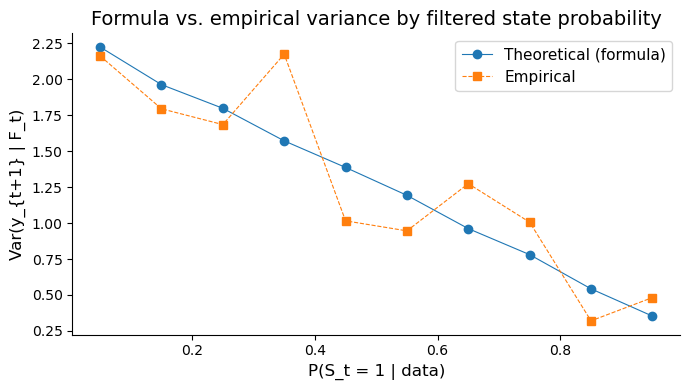

In [7]:
from methods.plotting import set_style
set_style(figsize=(7, 4))

# Precompute predicted mean E[y_{t+1} | F_t] for all t
pred_means = np.array([
    np.sum((alpha[t] @ P_true) * beta_true * y[t])
    for t in range(T - 1)
])
residuals = y[1:] - pred_means   # y_{t+1} - E[y_{t+1} | F_t]

bins    = np.linspace(0, 1, 11)
bin_idx = np.digitize(alpha[:-1, 0], bins) - 1

theoretical_per_bin = []
empirical_per_bin   = []
bin_centers         = []

for b in range(len(bins) - 1):
    mask = bin_idx == b
    if mask.sum() < 10:
        continue

    # Average theoretical conditional variance over time steps in bin
    w_bin     = alpha[:-1][mask]
    y_bin     = y[:-1][mask]
    theo_vars = []
    for i in range(mask.sum()):
        w_t      = w_bin[i]
        means_t  = beta_true * y_bin[i]
        mix_mean = np.sum(w_t * means_t)
        var_t    = np.sum(w_t * sigma_true**2) + np.sum(w_t * (means_t - mix_mean)**2)
        theo_vars.append(var_t)
    theoretical_per_bin.append(np.mean(theo_vars))

    # Empirical: mean squared residual (removes between-step mean variation)
    empirical_per_bin.append(np.mean(residuals[mask]**2))
    bin_centers.append((bins[b] + bins[b + 1]) / 2)

fig, ax = plt.subplots()
ax.plot(bin_centers, theoretical_per_bin, "o-",  label="Theoretical (formula)")
ax.plot(bin_centers, empirical_per_bin,   "s--", label="Empirical")
ax.set_xlabel("P(S_t = 1 | data)")
ax.set_ylabel("Var(y_{t+1} | F_t)")
ax.set_title("Formula vs. empirical variance by filtered state probability")
ax.legend()
fig.tight_layout()
fig.savefig("../plots/prediction_interval_variance_test.pdf", bbox_inches="tight", format="pdf")
plt.show()


### Convergence of empirical variance to theoretical with increasing T

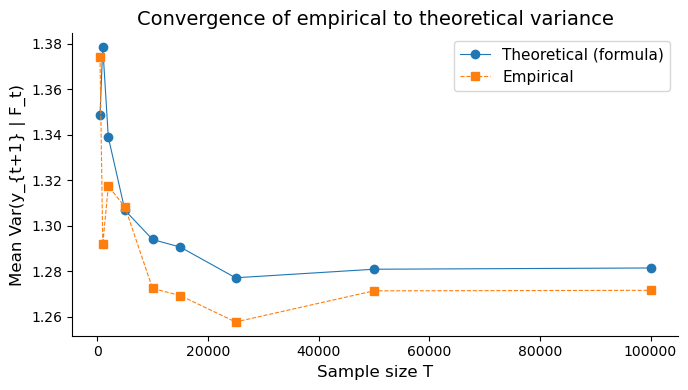

In [8]:
from methods.plotting import set_style
set_style(figsize=(7, 4))

T_values = [500, 1000, 2000, 5000, 10000, 15000, 25000, 50000, 100000]

theoretical_means = []
empirical_means   = []

for T_n in T_values:
    y_n, _ = simulate_rs_ar1(T_n, beta_true, sigma_true, P_true, seed=42)
    alpha_n, _, _ = forward_algorithm(y_n, beta_true, sigma_true, P_true)

    # Theoretical: average conditional variance over all t
    theo_vars = []
    for t in range(T_n - 1):
        w_t      = alpha_n[t] @ P_true
        means_t  = beta_true * y_n[t]
        mix_mean = np.sum(w_t * means_t)
        var_t    = np.sum(w_t * sigma_true**2) + np.sum(w_t * (means_t - mix_mean)**2)
        theo_vars.append(var_t)
    theoretical_means.append(np.mean(theo_vars))

    # Empirical: mean squared residual
    pred_means_n = np.array([
        np.sum((alpha_n[t] @ P_true) * beta_true * y_n[t])
        for t in range(T_n - 1)
    ])
    residuals_n = y_n[1:] - pred_means_n
    empirical_means.append(np.mean(residuals_n**2))

fig, ax = plt.subplots()
ax.plot(T_values, theoretical_means, "o-",  label="Theoretical (formula)")
ax.plot(T_values, empirical_means,   "s--", label="Empirical")
ax.set_xlabel("Sample size T")
ax.set_ylabel("Mean Var(y_{t+1} | F_t)")
ax.set_title("Convergence of empirical to theoretical variance")
ax.legend()
fig.tight_layout()
fig.savefig("../plots/prediction_interval_variance_convergence.pdf", bbox_inches="tight", format="pdf")
plt.show()
